# Exploratory Data Analysis (EDA)

## Objective

The objective of this Exploratory Data Analysis (EDA) is to understand the characteristics of Rossmann's historical sales data, identify patterns, detect anomalies, evaluate factors influencing sales, and generate business insights that will support feature engineering and sales forecasting.

---

## Analysis Roadmap

This notebook is organized into the following sections:

1. Dataset Overview
2. Univariate Analysis
3. Time-Based Analysis
4. Store Performance Analysis
5. Promotion Analysis
6. Correlation Analysis
7. Competition Analysis
8. Executive Summary

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

#Load Clean Dataset

df = pd.read_csv("/content/cleaned_sales.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

/tmp/ipykernel_2688/1757716979.py:17: DtypeWarning:

Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.



,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Week,Day,Quarter,DayName,Weekend
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN,2015,7,31,31,3,Friday,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,3,Friday,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,3,Friday,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN,2015,7,31,31,3,Friday,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN,2015,7,31,31,3,Friday,0


# Univariate Analysis

**Sales Distribution**

**Customers Distribution**

# Chart 1 — Sales Distribution:

**Business Question**

How are daily sales distributed across all Rossmann stores?

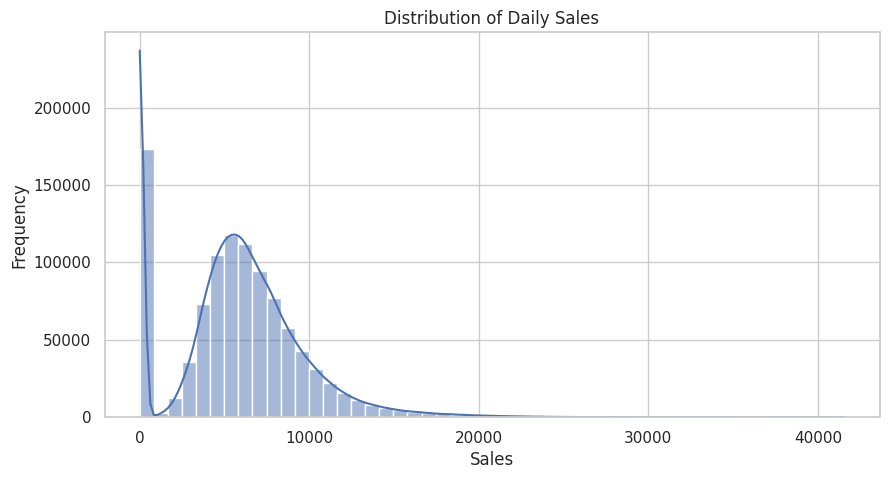

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

**Business Insight**

The distribution of daily sales is positively skewed, indicating that while most stores generate moderate daily revenue, a small number consistently achieve significantly higher sales. This highlights considerable variation in store performance across the network.

*Recommendation*

Rossmann should identify the operational strategies, product assortment, and promotional practices of top-performing stores and evaluate whether these strategies can be replicated in lower-performing locations.



# Chart 2 — Customers Distribution

**Business Question**

**How many customers typically visit Rossmann stores each day?**

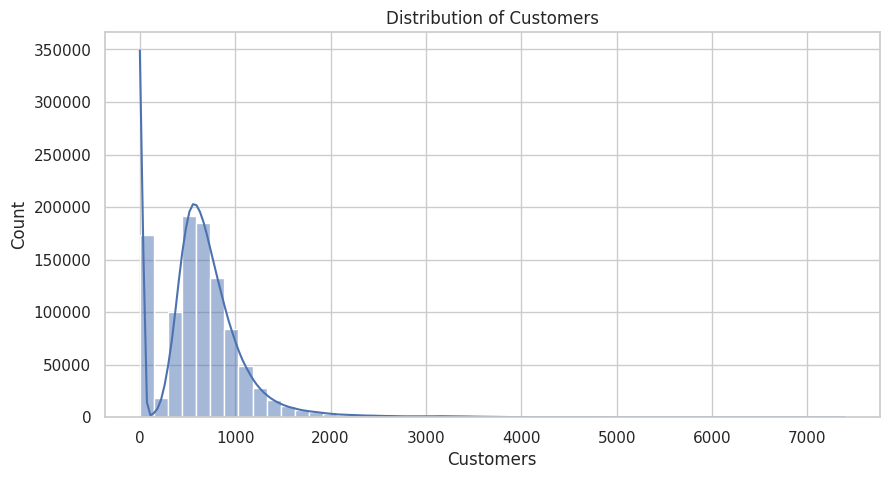

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Customers"], bins=50, kde=True)

plt.title("Distribution of Customers")

plt.show()

Observation

The distribution of customers is positively (right) skewed.
Most stores receive approximately 400–1000 customers per day.
The number of stores with very high customer traffic (>1500 customers) decreases rapidly.
A few stores experience exceptionally high customer visits, indicating the presence of outliers.
There are also some records with zero customers, likely representing days when stores were closed.

**Business Insight**

Customer traffic is unevenly distributed across Rossmann stores. While most stores experience moderate daily footfall, a small number consistently attract significantly more customers, which likely contributes to higher sales.

*Recommendation*

Rossmann should identify the factors driving high customer traffic in top-performing stores—such as location, promotions, or product assortment—and apply those strategies to improve customer visits in lower-performing stores.

# Time-Based Analysis

Monthly Sales

Day of Week

State Holiday

School Holiday


# Chart 3 — Monthly Sales Trend

**Business Question**

**Which months generate the highest and lowest sales?**

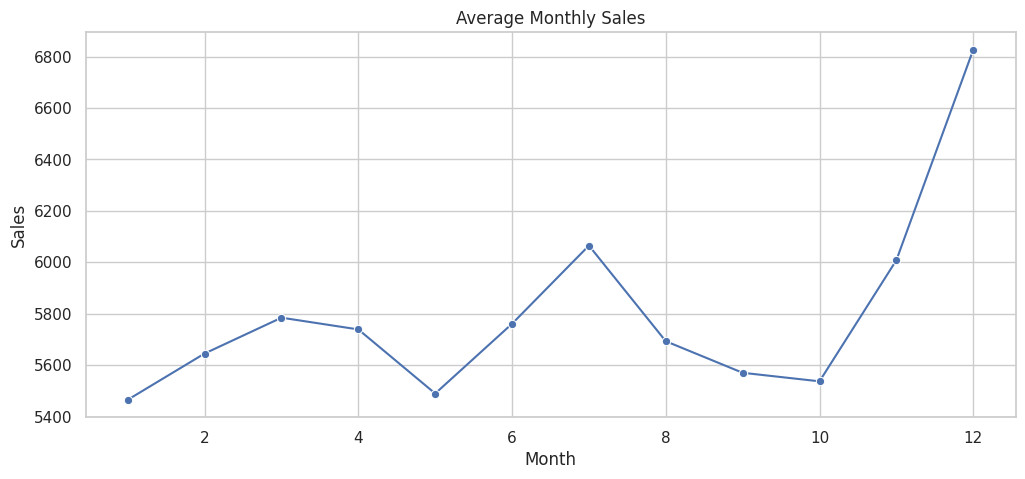

In [22]:
monthly_sales = df.groupby("Month")["Sales"].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_sales,
             x="Month",
             y="Sales",
             marker="o")

plt.title("Average Monthly Sales")

plt.show()

Observation

Average monthly sales fluctuate throughout the year, indicating seasonal demand patterns.
Sales gradually increase from January to March.
A decline is observed around May.
Sales recover and peak again in July.
Another slight decline occurs between August and October.
Sales increase sharply during November, with December recording the highest average sales of the year.

**Business Insight**

Customer purchasing behavior varies across different months, demonstrating clear seasonality. The substantial increase in sales during November and December likely reflects increased shopping activity associated with year-end events and festive demand.

*Recommendation*

Rossmann should prepare for higher customer demand during the final quarter by increasing inventory, staffing, and promotional planning. During lower-performing months, targeted marketing campaigns and promotional offers can help maintain stable sales performance.

# Chart 4 — Sales by Day of Week

**Business Question**

**Which days of the week contribute the most to revenue?**

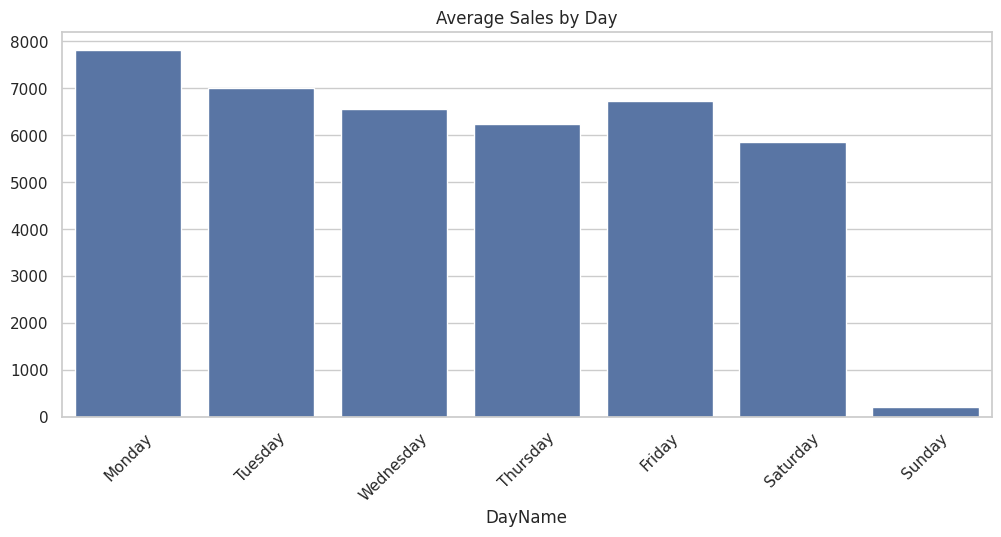

In [23]:
day_sales = df.groupby("DayName")["Sales"].mean().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(12,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title("Average Sales by Day")

plt.xticks(rotation=45)

plt.show()

Observation

Monday records the highest average sales.
Sales gradually decline during the week.
Sunday has almost no sales because most Rossmann stores remain closed.
Friday also performs relatively well compared to the middle of the week.

**Business Insight**

Customer purchasing activity is highest at the beginning of the week, suggesting that shoppers replenish household necessities after weekends. Sunday contributes negligible revenue due to store closures.

*Recommendation*

Allocate more inventory and staff on Mondays and Fridays.
Schedule maintenance and employee training on Sundays or other low-demand periods.

# Chart 5 — Holiday Analysis

***Business Question***

**How do state holidays affect store sales?**

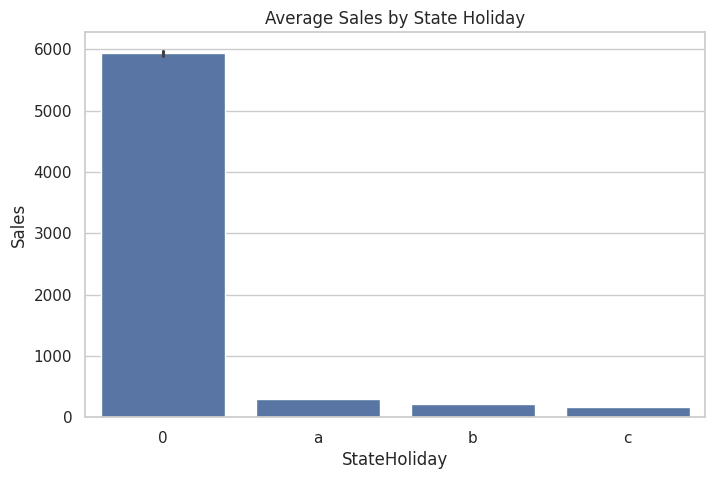

In [28]:
holiday_sales = (
    df.groupby("StateHoliday")["Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=holiday_sales,
    x="StateHoliday",
    y="Sales"
)

plt.title("Average Sales by State Holiday")

plt.show()

Observation

Regular business days (StateHoliday = 0) generate significantly higher sales.
Sales during holidays (a, b, c) are substantially lower.

**Business Insight**

State holidays reduce store traffic and operational hours, leading to decreased revenue.

*Recommendation*

Avoid stocking excessive inventory before state holidays.
Launch holiday-specific promotional campaigns before holidays to maximize sales.

# Chart 6 — School Holiday Analysis

**Business Question**

**Do school holidays influence customer purchasing behavior?**

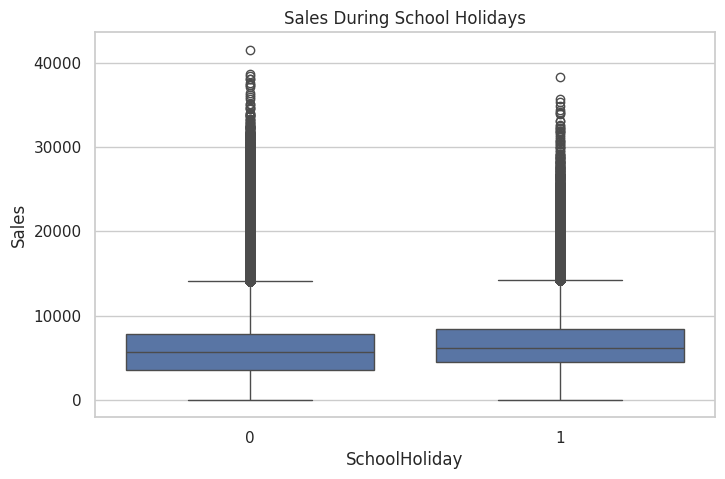

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="SchoolHoliday",
    y="Sales",
    data=df
)

plt.title("Sales During School Holidays")

plt.show()

Observation

Median sales during school holidays are slightly higher.
Sales variability remains similar between school holidays and normal days.

**Business Insight**

School holidays appear to have a modest positive influence on customer spending, likely due to families having more time for shopping.

*Recommendation*

Introduce family-oriented promotional campaigns during school holidays.
Increase inventory for frequently purchased family products during these periods.

# Chart 7 — Interactive Monthly Trend (Plotly)

**Business Question**

**Are there seasonal trends that management should consider for planning inventory and promotions?**

In [34]:
monthly = (
    df.groupby("Month")["Sales"]
      .sum()
      .reset_index()
)

fig = px.line(
    monthly,
    x="Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

Observation

Sales remain relatively stable from January to July.
There is a noticeable decline from August onward.
December shows a recovery but does not reach earlier peaks.

**Business Insight**

Sales demonstrate clear seasonal patterns, indicating that customer demand fluctuates throughout the year.

*Recommendation*

Use seasonal trends to improve demand forecasting.
Plan promotional campaigns during lower-performing months.
Adjust inventory and staffing according to expected seasonal demand.

# Store Performance Analysis

Top 10 Stores

Store Type

Assortment

# Chart 8 — Top 10 Stores

**Business Question**

**Which stores contribute the highest revenue?**

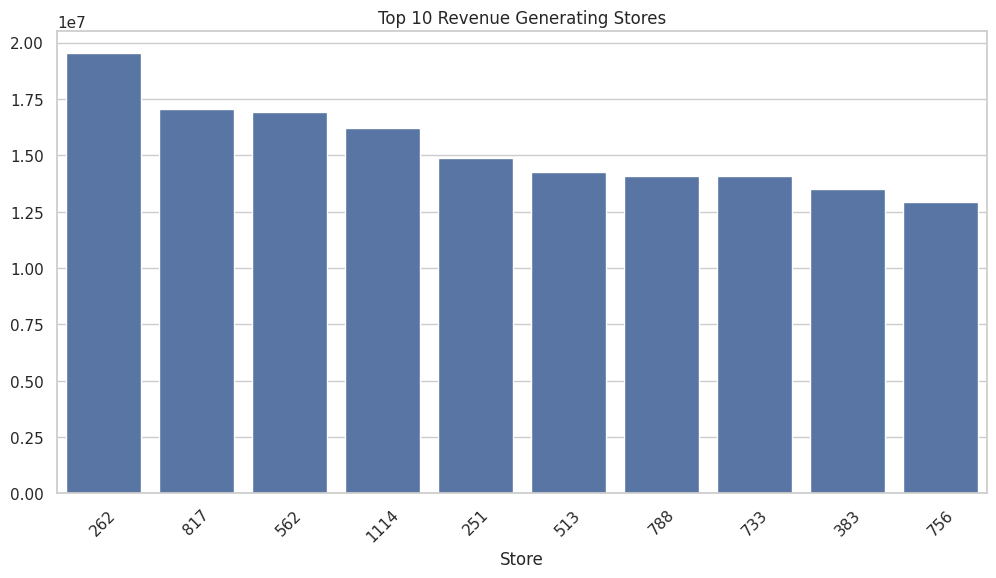

In [27]:
top_store = (
    df.groupby("Store")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_store.index.astype(str),
    y=top_store.values
)

plt.title("Top 10 Revenue Generating Stores")

plt.xticks(rotation=45)

plt.show()

Observation

Store 262 generates the highest total revenue.
Revenue differences among the top 10 stores are relatively small.

**Business Insight**

Certain stores consistently outperform others, indicating that factors such as location, customer demographics, or management practices contribute to higher sales.

*Recommendation*

Conduct detailed performance benchmarking on top-performing stores.
Replicate successful operational strategies across lower-performing stores.

# Chart 9 — Store Type Analysis

**Business Question**

**Which store types perform better in terms of revenue?**

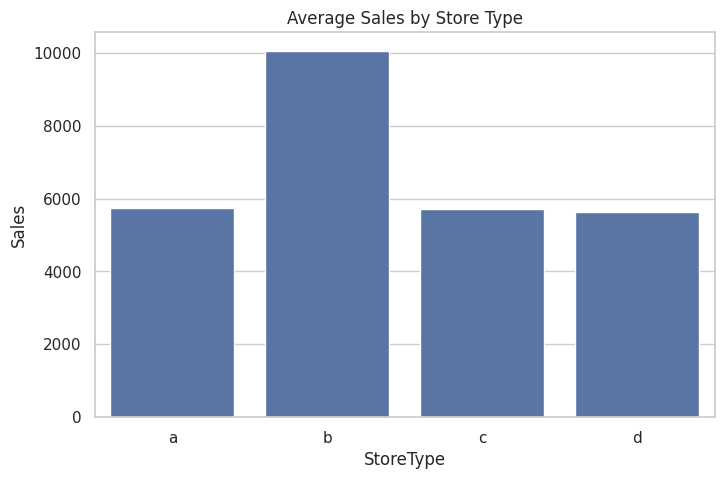

In [30]:
store_sales = (
    df.groupby("StoreType")["Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=store_sales,
    x="StoreType",
    y="Sales"
)

plt.title("Average Sales by Store Type")

plt.show()

Observation

Store Type b achieves substantially higher average sales than other store types.
Store Types a, c, and d exhibit similar sales levels.

**Business Insight**

Store format significantly influences sales performance, suggesting that business strategy and store design impact customer purchasing behavior.

*Recommendation*

Analyze the characteristics of Store Type b.
Apply successful practices from Store Type b to other store formats where feasible.

# Chart 10 — Assortment Analysis

**Business Question**

**Does the product assortment offered by stores impact sales performance?**

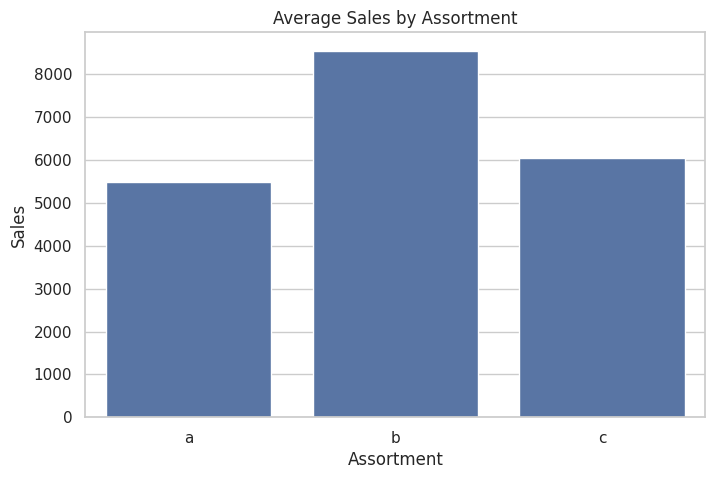

In [31]:
assortment_sales = (
    df.groupby("Assortment")["Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=assortment_sales,
    x="Assortment",
    y="Sales"
)

plt.title("Average Sales by Assortment")

plt.show()

Observation

Assortment b generates the highest average sales.
Assortment a records the lowest sales.

**Business Insight**

Stores offering a broader or more optimized product assortment attract higher customer spending.

*Recommendation*

Expand successful product assortments to additional stores.
Continuously evaluate product mix using customer purchasing behavior.

# Promotion Analysis

# Chart 11 — Promotion Impact

**Business Question**

**Do promotional campaigns significantly increase daily sales?**

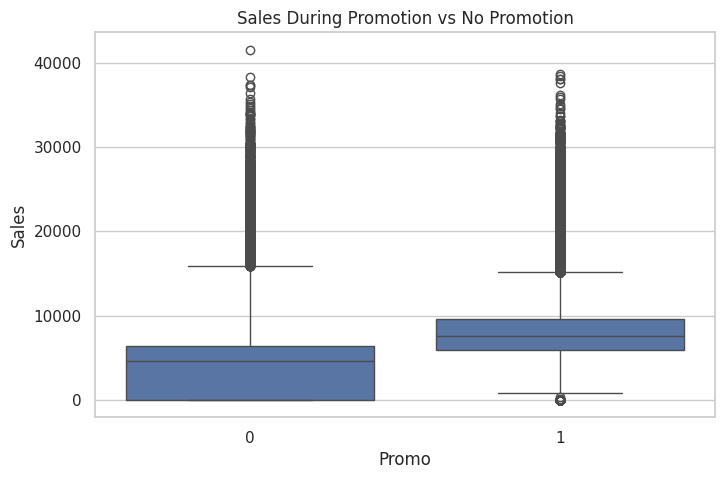

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Promo",
    y="Sales",
    data=df
)

plt.title("Sales During Promotion vs No Promotion")

plt.show()

Observation

Promotional periods have noticeably higher median sales.
The entire sales distribution shifts upward during promotions.

**Business Insight**

Promotions are strongly associated with increased daily revenue, indicating they effectively stimulate customer purchasing behavior.

*Recommendation*

Continue promotional campaigns during low-demand periods.
Measure promotional profitability to maximize return on investment.

# Correlation Analysis

# Chart 12 — Correlation Heatmap

**Business Question**

**Which business variables are most strongly associated with sales?**

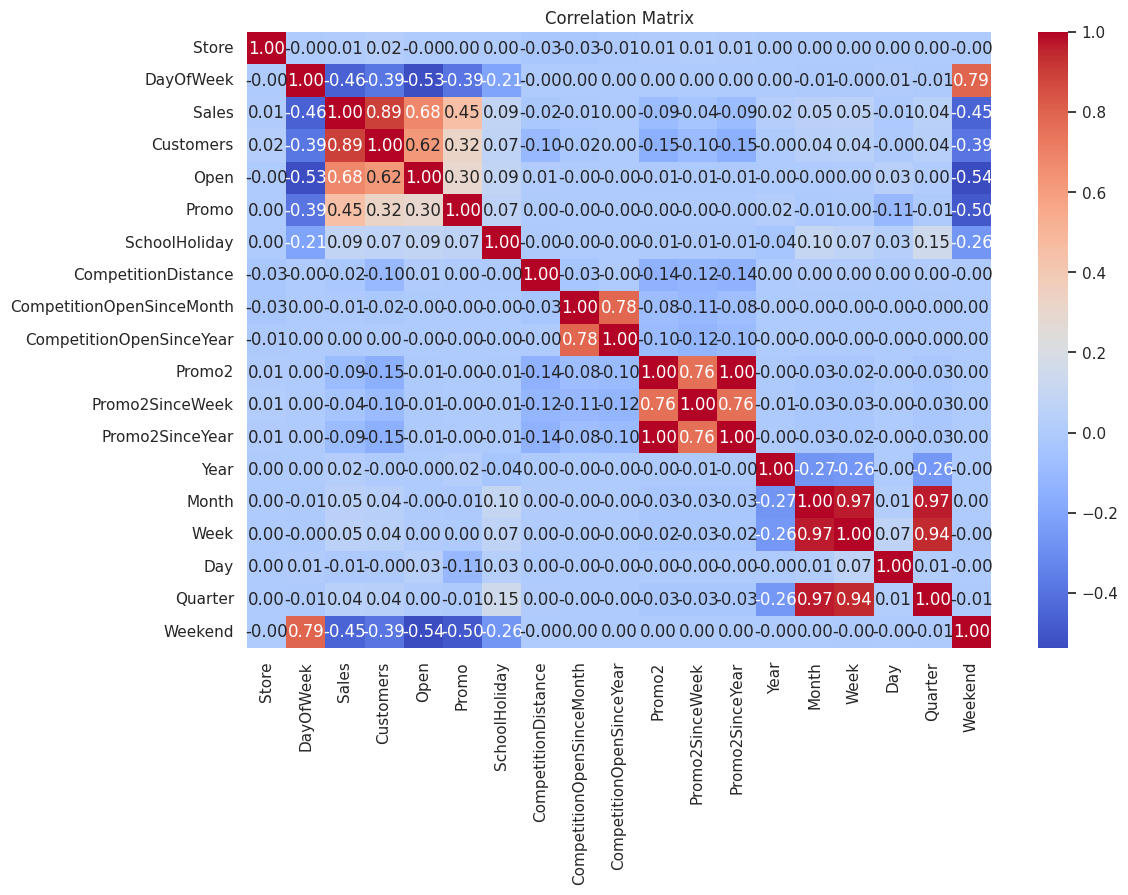

In [26]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Observation

Customers have the strongest positive correlation with Sales (≈0.89).
Promotions show a moderate positive relationship with Sales.
Open stores positively correlate with revenue.
Competition Distance exhibits little direct relationship with Sales.

**Business Insight**

Customer traffic is the primary driver of revenue, while promotional activities also contribute meaningfully to sales performance.

*Recommendation*

Prioritize customer acquisition strategies.
Include Customers, Promo, and Open status as key features in forecasting models.

# Chart 13 — Customer vs Sales

**Business Question**

 **Is there a relationship between customer traffic and sales revenue?**

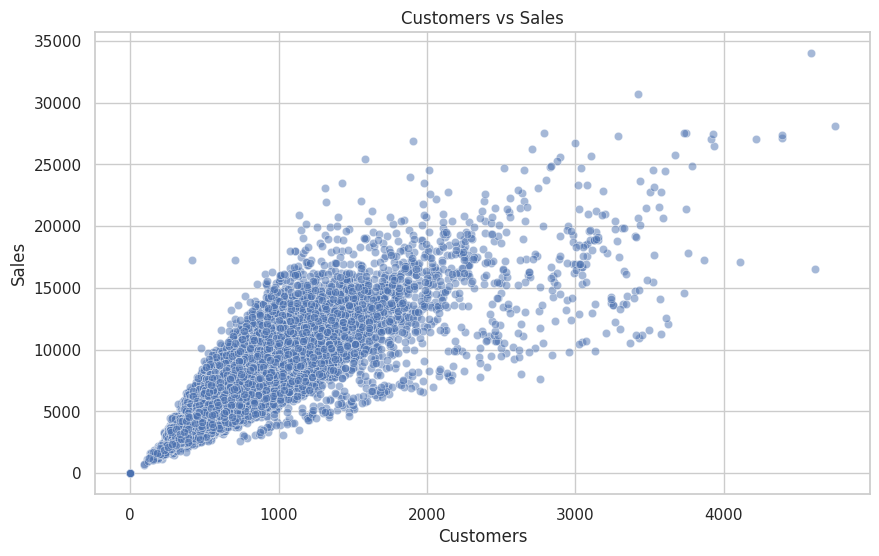

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(30000),
    x="Customers",
    y="Sales",
    alpha=0.5
)

plt.title("Customers vs Sales")

plt.show()

Observation

There is a strong positive linear relationship between customer count and sales.
Higher customer traffic generally leads to higher revenue.
A few high-sales outliers are present.

**Business Insight**

Revenue growth depends heavily on increasing customer footfall, making customer acquisition one of Rossmann's most important business objectives.

*Recommendation*

Invest in customer retention programs, loyalty initiatives, and targeted marketing campaigns.
Monitor customer traffic as a leading indicator of store performance.

# Competition Analysis

# Chart 14 — Competition Distance

**Business Question**

**Does proximity to competitors affect store sales?**

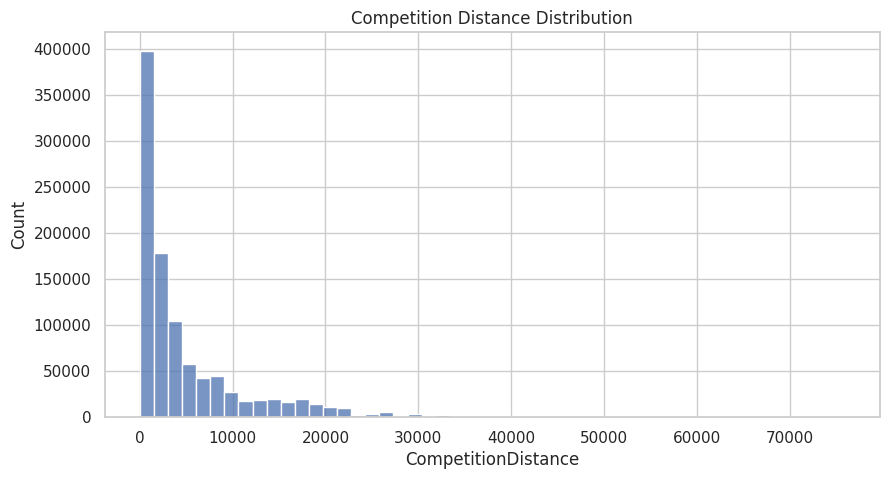

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CompetitionDistance"],
    bins=50
)

plt.title("Competition Distance Distribution")

plt.show()

# Chart 15 — Open vs Closed Stores

**Business Question**

**How much revenue is generated when stores remain operational?**

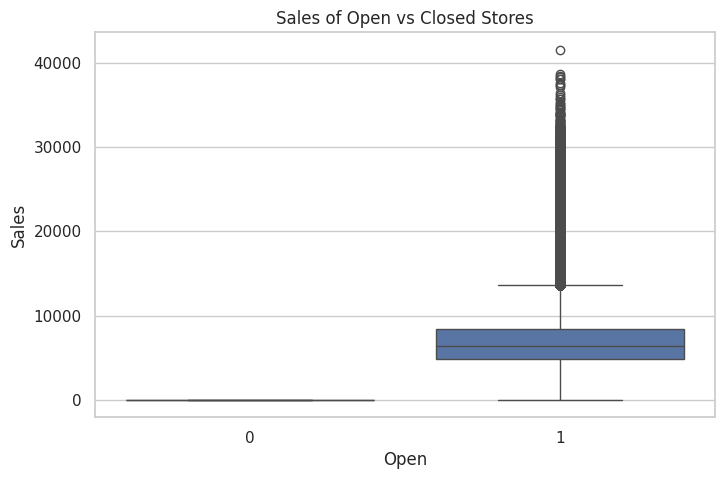

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Open",
    y="Sales",
    data=df
)

plt.title("Sales of Open vs Closed Stores")

plt.show()

Observation

Closed stores generate virtually no sales.
Open stores exhibit a wide range of sales depending on demand and store characteristics.

**Business Insight**

Operational availability is fundamental to revenue generation. Any unexpected closure directly impacts daily sales.

*Recommendation*

Minimize unplanned store closures.
Improve operational planning, staffing, and maintenance schedules to maximize store availability.

# Executive Summary

## Overview

This Exploratory Data Analysis (EDA) examined historical sales data from Rossmann stores to identify key business patterns, understand the factors influencing sales performance, and generate actionable insights for business decision-making and sales forecasting.

The analysis explored sales behavior across different stores, promotions, holidays, customer traffic, store characteristics, and competitive factors.

---

## Key Findings

### Sales Performance
- Daily sales exhibit a positively skewed distribution, with most stores generating moderate sales while a small number consistently achieve exceptionally high revenue.
- Significant variability exists in sales performance across different stores, indicating opportunities for performance optimization.

### Customer Behavior
- Customer count demonstrates a strong positive relationship with daily sales, suggesting that customer traffic is one of the primary drivers of revenue generation.
- Stores attracting more customers consistently report higher sales volumes.

### Promotional Effectiveness
- Promotional campaigns are associated with increased daily sales, indicating that promotions are an effective strategy for boosting customer purchases and overall revenue.

### Seasonal and Time-Based Trends
- Sales vary across different months and days of the week, highlighting clear seasonal and temporal purchasing patterns.
- Holiday periods also influence customer purchasing behavior, although the impact differs between school holidays and state holidays.

### Store Characteristics
- Store type and product assortment contribute to differences in sales performance, suggesting that operational strategies and product offerings influence customer demand.

### Competition Analysis
- Competition-related variables provide valuable context for understanding store performance and may influence sales depending on market conditions and store location.

---

## Business Recommendations

Based on the analysis, Rossmann management should consider the following actions:

- Increase promotional campaigns during historically low-performing periods while monitoring campaign profitability.
- Replicate successful operational practices from top-performing stores across lower-performing locations.
- Optimize inventory planning based on seasonal demand patterns to reduce stock shortages and excess inventory.
- Allocate staffing resources according to expected customer traffic during peak sales periods.
- Continue investing in customer acquisition and retention initiatives to increase store footfall.
- Utilize the insights obtained from this analysis to support accurate sales forecasting and data-driven business planning.

---

## Conclusion

The exploratory analysis identified several important factors influencing Rossmann's sales performance, including promotions, customer traffic, seasonality, and store characteristics. These insights provide a strong foundation for the next stages of the project, including SQL-based business analysis, feature engineering, predictive modeling, and the development of an interactive business intelligence dashboard.